# ECG Arrhythmia Pipeline — Live Monitor

Reads from two sinks in real time:
- **Delta Lake** — every processed 30-second window (signal stats + detection result)
- **PostgreSQL** — alert rows only (`requires_alert = True`)

**Prerequisites:** `docker-compose up -d` → `ecg_stream_processor.py` → `ecg_producer.py`

Run **Cell 1–4** once to set up, then either:
- **Cell 5** — single snapshot
- **Cell 6** — auto-refresh loop (interrupt kernel to stop)

In [1]:
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import subprocess, sys
try:
    from deltalake import DeltaTable
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'deltalake', '-q'])
    from deltalake import DeltaTable

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import psycopg2
from datetime import datetime
from IPython.display import clear_output
import time
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.5,
    'lines.linewidth':  1.3,
})
print('Setup complete.')

Setup complete.


In [7]:
# ── Config ────────────────────────────────────────────────────────────────────
DELTA_PATH  = '../data/delta_lake/processed_signals'
PG_HOST     = 'localhost'
PG_PORT     = 5432
PG_DB       = 'ecg_pipeline'
PG_USER     = 'ecg_user'
PG_PASSWORD = 'change_me_strong_password'

SEVERITY_COLORS = {
    'NORMAL':   '#3fb950',
    'LOW':      '#79c0ff',
    'MEDIUM':   '#d29922',
    'HIGH':     '#f78166',
    'CRITICAL': '#ff4444',
}
TYPE_COLORS = {
    'NORMAL':               '#3fb950',
    'TACHYCARDIA':          '#f78166',
    'BRADYCARDIA':          '#79c0ff',
    'ATRIAL_ECTOPIC':       '#d2a8ff',
    'VENTRICULAR_ECTOPIC':  '#ff7b72',
    'POSSIBLE_AFIB':        '#ffa657',
    'UNKNOWN':              '#8b949e',
}

In [8]:
# ── Data loaders ──────────────────────────────────────────────────────────────

def load_delta(max_windows=600):
    """Read recent processed windows from Delta Lake (no Spark needed)."""
    path = Path(DELTA_PATH)
    if not path.exists():
        return pd.DataFrame()
    try:
        df = DeltaTable(str(path)).to_pandas()
        if df.empty:
            return df
        for col in ('window_start', 'window_end', 'processing_ts'):
            if col in df.columns:
                s = pd.to_datetime(df[col])
                df[col] = s.dt.tz_convert(None) if s.dt.tz else s
        return df.sort_values('window_start').tail(max_windows)
    except Exception as e:
        msg = str(e)
        if 'No files in log segment' not in msg and 'No such file' not in msg:
            print(f'[Delta Lake] {e}')
        return pd.DataFrame()


def load_alerts(limit=200):
    """Read recent alert rows from PostgreSQL ecg_alerts table."""
    try:
        conn = psycopg2.connect(
            host=PG_HOST, port=PG_PORT, dbname=PG_DB,
            user=PG_USER, password=PG_PASSWORD, connect_timeout=3,
        )
        df = pd.read_sql(
            'SELECT patient_id, window_start, arrhythmia_type, severity, '
            'triggered_rule, heart_rate_bpm, beat_count, arrhythmia_count '
            'FROM ecg_alerts ORDER BY window_start DESC LIMIT %s',
            conn, params=(limit,),
        )
        conn.close()
        return df
    except Exception as e:
        print(f'[PostgreSQL] {e}')
        return pd.DataFrame()


def kpis(df, alerts):
    return {
        'windows':  len(df),
        'patients': df['patient_id'].nunique() if not df.empty else 0,
        'alerts':   len(alerts),
        'critical': int((alerts['severity'] == 'CRITICAL').sum()) if not alerts.empty else 0,
        'last_ts':  df['window_start'].max().strftime('%H:%M:%S') if not df.empty else '—',
    }

print('Loaders ready.')

Loaders ready.


In [9]:
# ── Dashboard renderer ────────────────────────────────────────────────────────

def render(df, alerts):
    stats = kpis(df, alerts)

    fig = plt.figure(figsize=(18, 12), constrained_layout=True)
    fig.suptitle(
        f"ECG Arrhythmia Pipeline  ·  Live Monitor  ·  {datetime.now().strftime('%Y-%m-%d  %H:%M:%S')}",
        fontsize=13, fontweight='bold', color='#e6edf3',
    )
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[0.35, 1, 1])

    # ── Row 0: KPI tiles ──────────────────────────────────────
    ax_kpi = fig.add_subplot(gs[0, :])
    ax_kpi.axis('off')
    tiles = [
        ('Windows Processed',  str(stats['windows']),   '#79c0ff'),
        ('Active Patients',    str(stats['patients']),  '#3fb950'),
        ('Total Alerts',       str(stats['alerts']),    '#d29922'),
        ('Critical Alerts',    str(stats['critical']),  '#ff4444'),
        ('Last Window',        stats['last_ts'],         '#8b949e'),
    ]
    for i, (label, value, color) in enumerate(tiles):
        x = 0.09 + i * 0.205
        ax_kpi.text(x, 0.72, value, transform=ax_kpi.transAxes,
                    fontsize=26, fontweight='bold', color=color, ha='center', va='center')
        ax_kpi.text(x, 0.18, label, transform=ax_kpi.transAxes,
                    fontsize=9,  color='#8b949e',  ha='center', va='center')
        if i < len(tiles) - 1:
            x_div = 0.09 + (i + 0.5) * 0.205 + 0.09
            ax_kpi.plot([x_div, x_div], [0.05, 0.95],
                        transform=ax_kpi.transAxes,
                        color='#30363d', linewidth=0.8)

    # ── Row 1 left+centre: Heart rate timeline ────────────────
    ax_hr = fig.add_subplot(gs[1, :2])
    if not df.empty:
        for pid, grp in df.groupby('patient_id'):
            grp = grp.sort_values('window_start')
            ax_hr.plot(grp['window_start'], grp['heart_rate_bpm'],
                       alpha=0.7, label=f'Patient {pid}')
            dot_colors = [TYPE_COLORS.get(t, '#8b949e')
                          for t in grp['arrhythmia_type'].fillna('UNKNOWN')]
            ax_hr.scatter(grp['window_start'], grp['heart_rate_bpm'],
                          c=dot_colors, s=22, zorder=5)
    ax_hr.axhline(60,  color='#79c0ff', linestyle='--', linewidth=0.9,
                  alpha=0.7, label='Bradycardia < 60')
    ax_hr.axhline(100, color='#f78166', linestyle='--', linewidth=0.9,
                  alpha=0.7, label='Tachycardia > 100')
    ax_hr.set_title('Heart Rate per 30s Window  (dot colour = detection type)', color='#e6edf3')
    ax_hr.set_ylabel('bpm', color='#8b949e')
    ax_hr.legend(fontsize=7, loc='upper right', framealpha=0.3)
    ax_hr.grid(True, axis='y')
    ax_hr.tick_params(axis='x', rotation=20)
    if df.empty:
        ax_hr.text(0.5, 0.5, 'Waiting for data…',
                   transform=ax_hr.transAxes, ha='center', va='center',
                   color='#8b949e', fontsize=12)

    # ── Row 1 right: Detection type distribution ──────────────
    ax_type = fig.add_subplot(gs[1, 2])
    if not df.empty and 'arrhythmia_type' in df.columns:
        counts = df['arrhythmia_type'].value_counts()
        colors = [TYPE_COLORS.get(t, '#8b949e') for t in counts.index]
        ax_type.barh(counts.index, counts.values, color=colors)
        ax_type.set_title('Detection Results\n(all windows)', color='#e6edf3')
        ax_type.set_xlabel('Window count', color='#8b949e')
        ax_type.grid(True, axis='x')
        for bar, val in zip(ax_type.patches, counts.values):
            ax_type.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                         str(val), va='center', fontsize=8, color='#8b949e')
    else:
        ax_type.text(0.5, 0.5, 'No data yet',
                     transform=ax_type.transAxes, ha='center', va='center', color='#8b949e')
        ax_type.set_title('Detection Results', color='#e6edf3')

    # ── Row 2 left: Alert severity breakdown ──────────────────
    ax_sev = fig.add_subplot(gs[2, 0])
    if not alerts.empty:
        sev = alerts['severity'].value_counts()
        colors = [SEVERITY_COLORS.get(s, '#8b949e') for s in sev.index]
        bars = ax_sev.bar(sev.index, sev.values, color=colors)
        ax_sev.set_title('Alert Severity', color='#e6edf3')
        ax_sev.set_ylabel('Count', color='#8b949e')
        ax_sev.tick_params(axis='x', rotation=15)
        ax_sev.grid(True, axis='y')
        for bar, val in zip(bars, sev.values):
            ax_sev.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                        str(val), ha='center', fontsize=9, color='#e6edf3')
    else:
        ax_sev.text(0.5, 0.5, 'No alerts yet',
                    transform=ax_sev.transAxes, ha='center', va='center', color='#8b949e')
        ax_sev.set_title('Alert Severity', color='#e6edf3')

    # ── Row 2 centre+right: Recent alerts table ───────────────
    ax_tbl = fig.add_subplot(gs[2, 1:])
    ax_tbl.axis('off')
    ax_tbl.set_title('Recent Alerts  (latest 8)', color='#e6edf3', loc='left')
    if not alerts.empty:
        cols = ['patient_id', 'arrhythmia_type', 'severity', 'heart_rate_bpm', 'triggered_rule']
        disp = alerts[cols].head(8).copy()
        disp['heart_rate_bpm'] = disp['heart_rate_bpm'].round(1)
        disp.columns = ['Patient', 'Type', 'Severity', 'HR (bpm)', 'Triggered Rule']
        tbl = ax_tbl.table(
            cellText=disp.values,
            colLabels=disp.columns,
            cellLoc='left', loc='center',
            bbox=[0, 0, 1, 0.92],
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        for (row, col), cell in tbl.get_celld().items():
            cell.set_edgecolor('#30363d')
            if row == 0:
                cell.set_facecolor('#21262d')
                cell.set_text_props(color='#e6edf3', fontweight='bold')
            else:
                cell.set_facecolor('#161b22' if row % 2 else '#1c2128')
                sev_val = disp.iloc[row - 1]['Severity'] if row <= len(disp) else ''
                color = SEVERITY_COLORS.get(sev_val, '#e6edf3') if col == 2 else '#e6edf3'
                cell.set_text_props(color=color)
    else:
        ax_tbl.text(0.5, 0.5,
                    'No alerts yet — arrhythmia events will appear here as they are detected.',
                    transform=ax_tbl.transAxes, ha='center', va='center',
                    color='#8b949e', fontsize=10)

    plt.show()

print('Dashboard renderer ready.')

Dashboard renderer ready.


## Single Snapshot
Run once to see current pipeline state.

[PostgreSQL] connection to server at "localhost" (::1), port 5432 failed: FATAL:  password authentication failed for user "ecg_user"

Delta Lake : 0 windows
PostgreSQL : 0 alerts


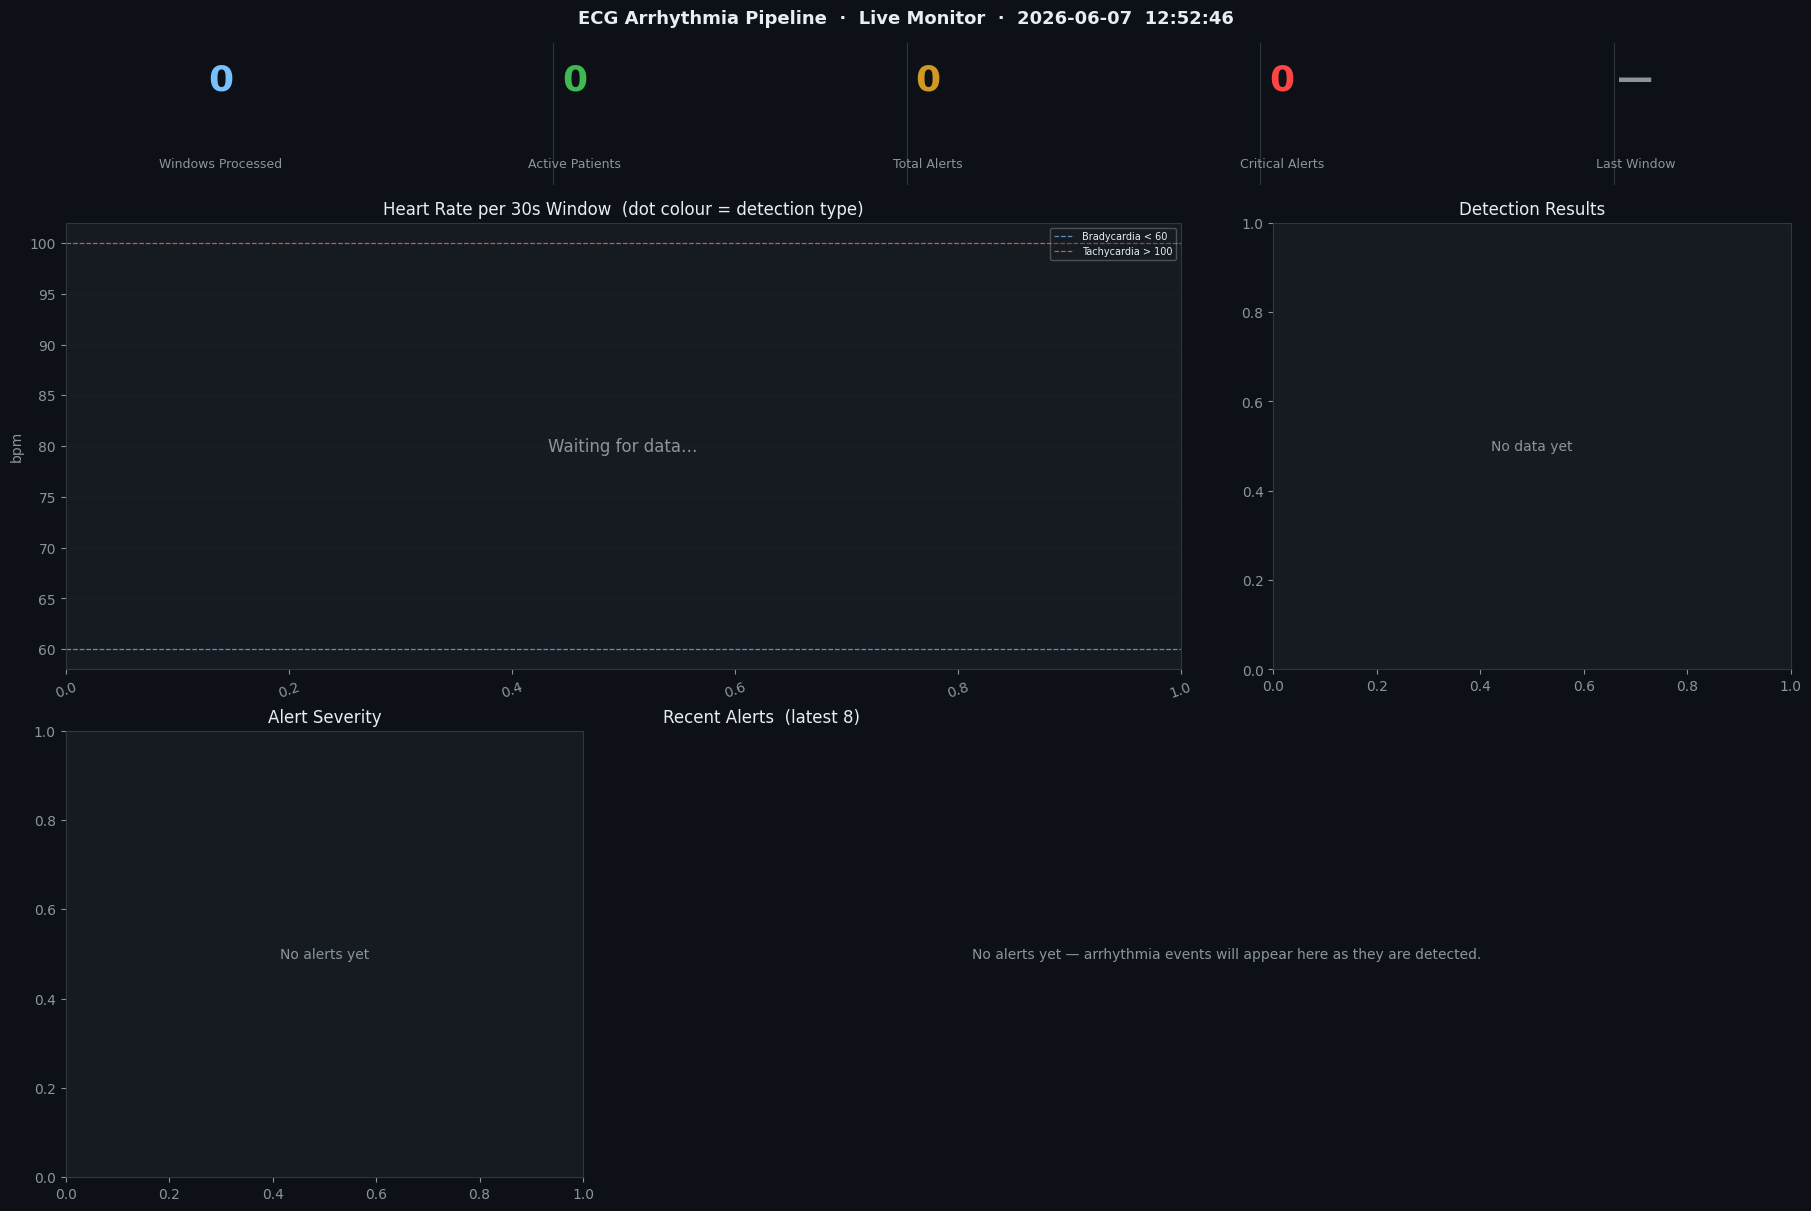

In [10]:
df     = load_delta()
alerts = load_alerts()
print(f'Delta Lake : {len(df)} windows')
print(f'PostgreSQL : {len(alerts)} alerts')
render(df, alerts)

## Auto-Refresh Loop
Polls Delta Lake and PostgreSQL every 10 seconds and redraws the dashboard.

**Stop:** `Kernel → Interrupt Kernel` (or press the ■ button in the toolbar).

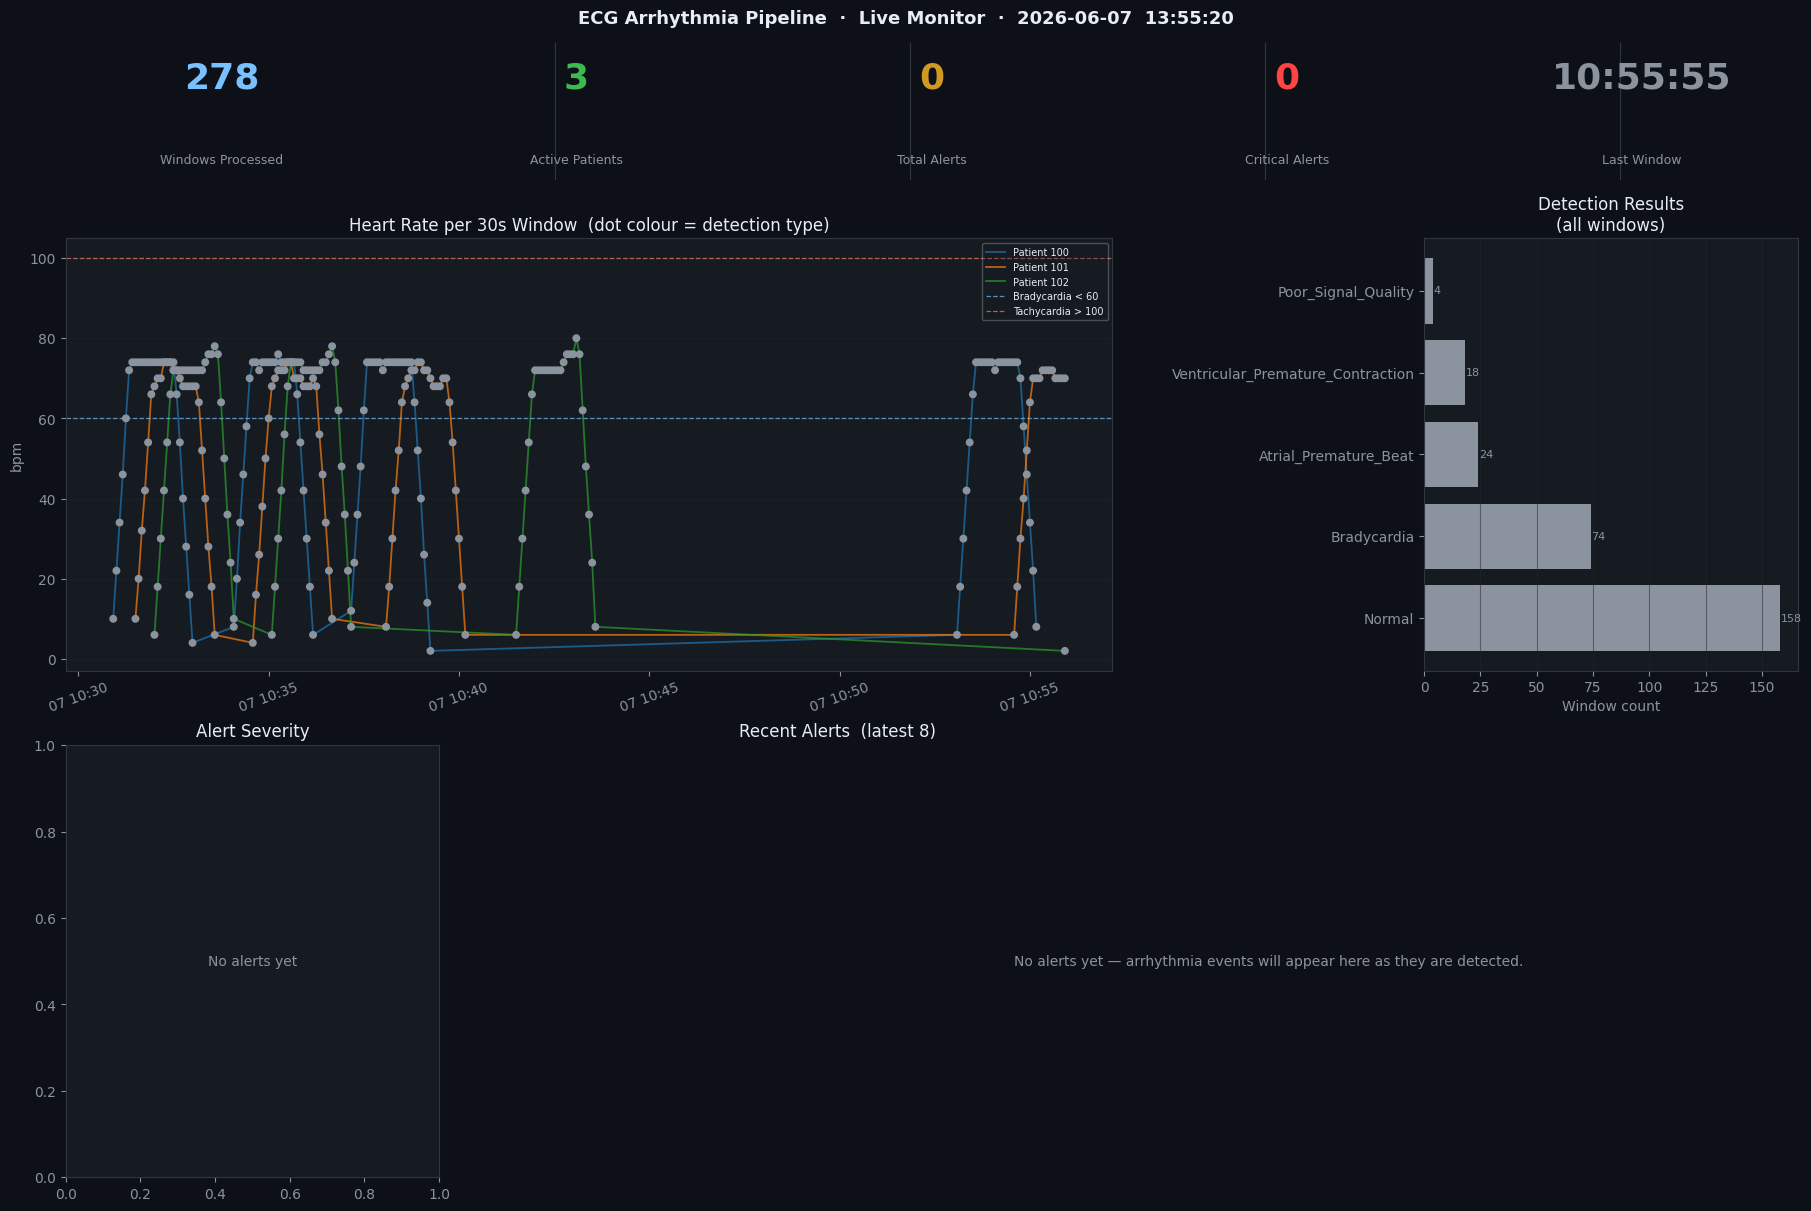

[PostgreSQL] connection to server at "localhost" (::1), port 5432 failed: FATAL:  password authentication failed for user "ecg_user"



In [ ]:
REFRESH_SECS = 10

print(f'Auto-refresh every {REFRESH_SECS}s — interrupt kernel to stop')
while True:
    df     = load_delta()
    alerts = load_alerts()
    clear_output(wait=True)
    render(df, alerts)
    time.sleep(REFRESH_SECS)